# Hospital Insurance Claims Analytics

Explore data quality, operational KPIs, financial summaries, and claim patterns from the loaded claims dataset.

## 1. Setup and imports

Load analysis dependencies and project modules.

In [1]:
import sys
import os

sys.path.append(os.path.abspath("src"))

import pandas as pd
import matplotlib.pyplot as plt

from database import load_claims
from data_validation import validate_all
from kpi_calculation import ClaimsKPI

## 2. Load claims data

Load claims from SQL Server. If the database is unavailable, the loader falls back to its sample dataset.

In [2]:
df = load_claims()

print("Rows loaded:", len(df))
df.head()

Rows loaded: 15


c:\Ravi\hospital-insurance-claims-analytics\03_Python_Analysis\src\database.py:86: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,claim_id,patient_id,patient_name,company_id,company_name,dept_id,dept_name,claim_type,claimed_amount,approved_amount,paid_amount,status,submission_date,decision_date,rejection_reason
0,1001,1,Patient_001,1,Star Health,1,Cardiology,INPATIENT,120000.0,100000.0,100000.0,SETTLED,2025-01-05,2025-01-20,NaN
1,1002,2,Patient_002,2,HDFC Ergo,2,Orthopedics,OUTPATIENT,25000.0,20000.0,20000.0,APPROVED,2025-01-08,2025-01-18,NaN
2,1003,3,Patient_003,3,ICICI Lombard,3,Neurology,INPATIENT,200000.0,0.0,0.0,DENIED,2025-01-10,2025-02-20,Pre-authorization missing
3,1004,4,Patient_004,4,Bajaj Allianz,4,Oncology,INPATIENT,350000.0,300000.0,280000.0,APPROVED,2025-01-12,2025-02-15,NaN
4,1005,5,Patient_005,5,Niva Bupa,5,General Surgery,OUTPATIENT,40000.0,0.0,0.0,PENDING,2025-01-15,None,NaN


## 3. Validate the data

Check the loaded claims before calculating metrics.

In [3]:
report = validate_all(df)
report

{'row_count': 15,
 'missing_columns': [],
 'nulls': {'decision_date': 2},
 'negative_amount_rows': 0,
 'date_order_issues': 0,
 'invalid_status_rows': 0}

## 4. Initialize KPI calculations

Set the processing-time threshold used to identify delayed claims.

In [4]:
kpi = ClaimsKPI(df, threshold_days=30)

## 5. Claim volume and rates

In [5]:
print("Total Claims   :", kpi.total_claims())
print("Approval Rate  :", kpi.approval_rate(), "%")
print("Denial Rate    :", kpi.denial_rate(), "%")
print("Avg Proc Days  :", kpi.avg_processing_time())

kpi.claims_by_status()

Total Claims   : 15
Approval Rate  : 76.92 %
Denial Rate    : 23.08 %
Avg Proc Days  : 20.5


,status,count,percentage
0,APPROVED,7,46.67
1,DENIED,3,20.00
2,SETTLED,3,20.00
3,PENDING,2,13.33


## 6. Rejection reasons

In [6]:
kpi.rejection_reasons()

,rejection_reason,count
0,Pre-authorization missing,1
1,Non-covered procedure,1
2,Duplicate claim,1


## 7. Delayed claims

List claims whose processing time exceeds the 30-day threshold.

In [7]:
delayed = kpi.delayed_claims()
print("Delayed claims:", len(delayed))

delayed[["claim_id", "company_name", "dept_name",
         "processing_days", "status"]].head(10)

Delayed claims: 5


,claim_id,company_name,dept_name,processing_days,status
2,1003,ICICI Lombard,Neurology,41.0,DENIED
3,1004,Bajaj Allianz,Oncology,34.0,APPROVED
7,1008,ICICI Lombard,Orthopedics,39.0,DENIED
9,1010,Niva Bupa,Oncology,37.0,APPROVED
11,1012,HDFC Ergo,General Surgery,43.0,DENIED


## 8. Financial summary

In [8]:
kpi.financial_summary()

{'total_claimed': 2155000.0,
 'total_approved': 1304000.0,
 'total_paid': 1234000.0,
 'claim_to_approval_gap': 851000.0,
 'approval_to_payment_gap': 70000.0}

## 9. Insurance company comparison

In [9]:
kpi.company_comparison()

,company_name,total_claims,approved,denied,approval_rate,denial_rate,avg_processing_days,total_claimed,total_paid
0,Bajaj Allianz,3,3,0,100.00,0.00,18.0,640000.0,525000.0
1,HDFC Ergo,3,2,1,66.67,33.33,22.3,355000.0,170000.0
2,ICICI Lombard,3,1,2,33.33,66.67,28.0,430000.0,9000.0
3,Niva Bupa,3,1,0,100.00,0.00,37.0,575000.0,400000.0
4,Star Health,3,3,0,100.00,0.00,8.3,155000.0,130000.0


## 10. Department analysis

In [10]:
kpi.department_analysis()

,dept_name,total_claims,denied,denial_rate,avg_processing_days,total_claimed
0,Cardiology,3,0,0.00,11.3,320000.0
2,Neurology,3,1,50.00,23.0,265000.0
4,Orthopedics,3,1,33.33,21.3,505000.0
1,General Surgery,2,1,100.00,43.0,190000.0
3,Oncology,2,0,0.00,35.5,850000.0
5,Pediatrics,2,0,0.00,4.5,25000.0


## 11. Investigate an individual claim

In [11]:
kpi.claim_lookup(1003)

,claim_id,patient_id,patient_name,company_id,company_name,dept_id,dept_name,claim_type,claimed_amount,approved_amount,paid_amount,status,submission_date,decision_date,rejection_reason,processing_days
2,1003,3,Patient_003,3,ICICI Lombard,3,Neurology,INPATIENT,200000.0,0.0,0.0,DENIED,2025-01-10,2025-02-20,Pre-authorization missing,41.0


## 12. Claims by status

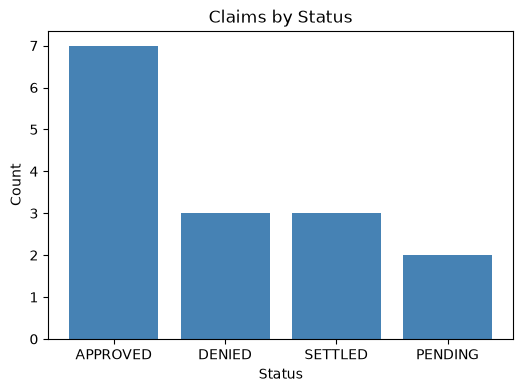

In [12]:
status_counts = kpi.claims_by_status()

plt.figure(figsize=(6, 4))
plt.bar(status_counts["status"], status_counts["count"], color="steelblue")
plt.title("Claims by Status")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

## 13. Financial totals

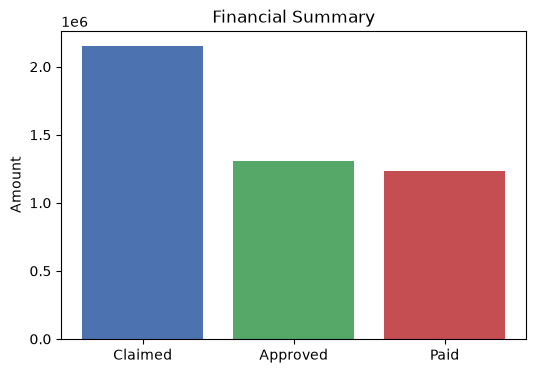

In [13]:
financials = kpi.financial_summary()

labels = ["Claimed", "Approved", "Paid"]
values = [financials["total_claimed"], financials["total_approved"], financials["total_paid"]]

plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=["#4C72B0", "#55A868", "#C44E52"])
plt.title("Financial Summary")
plt.ylabel("Amount")
plt.show()

## 14. Rejection reasons

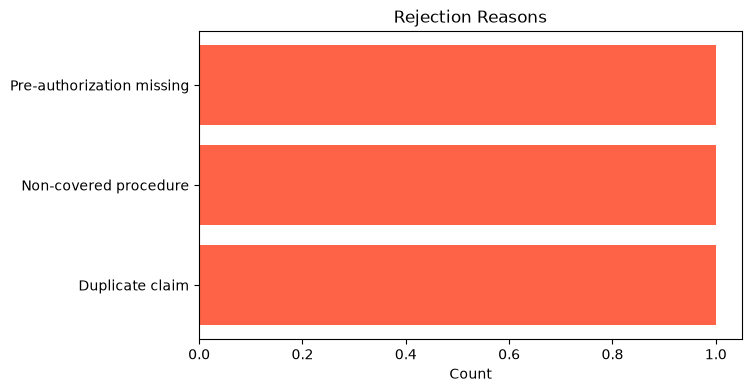

In [14]:
rejection_counts = kpi.rejection_reasons()

if not rejection_counts.empty:
    plt.figure(figsize=(7, 4))
    plt.barh(rejection_counts["rejection_reason"], rejection_counts["count"], color="tomato")
    plt.title("Rejection Reasons")
    plt.xlabel("Count")
    plt.gca().invert_yaxis()
    plt.show()

## 15. Findings and recommendations

Record conclusions after reviewing the outputs above.

### Key findings

- Total claims processed and the analysis period.
- Approval rate compared with denial rate.
- Main rejection reasons and the number of claims delayed beyond 30 days.
- Insurance companies with the highest denial rates and departments with the most rejections.
- Gaps between claimed and approved amounts, and between approved and paid amounts.

### Recommendations

- Follow up on claims pending beyond 30 days.
- Address frequent rejection reasons with process improvements.
- Prioritize review of insurance companies with high denial rates.
- Investigate departments with unusually high rejection volumes.